In [ ]:
!pip install -q neo4j

In [ ]:
import neo4j

print("Neo4j Python Driver Version:", neo4j.__version__)

Neo4j Python Driver Version: 6.3.1


In [ ]:
from getpass import getpass
from neo4j import GraphDatabase

URI = "neo4j+s://c2f5effc.databases.neo4j.io"
USERNAME = "c2f5effc"
PASSWORD = getpass("Password: ")

driver = GraphDatabase.driver(
    URI,
    auth=(USERNAME, PASSWORD)
)

driver.verify_connectivity()

print("Connected successfully")

Password: ··········
Connected successfully


In [ ]:
result = driver.execute_query(
    "SHOW HOME DATABASE"
)

for record in result.records:
    print(record.data())

{'name': 'c2f5effc', 'type': 'standard', 'aliases': [], 'access': 'read-write', 'address': 'p-mt-2a41353b6b9a-2-0173.production-orch-0695.neo4j.io:7687', 'role': 'primary', 'writer': True, 'requestedStatus': 'online', 'currentStatus': 'online', 'statusMessage': '', 'constituents': []}


In [ ]:
DATABASE = result.records[0]["name"]

print("Database =", DATABASE)

Database = c2f5effc


In [ ]:
result = driver.execute_query(
    """
    RETURN 'Hello Neo4j' AS message
    """,
    database_=DATABASE
)

print(result.records[0]["message"])

Hello Neo4j


In [ ]:
result = driver.execute_query(
    """
    MATCH (n)
    RETURN count(n) AS total_nodes
    """,
    database_=DATABASE
)

print("จำนวน Node =", result.records[0]["total_nodes"])

จำนวน Node = 30


In [ ]:
result = driver.execute_query(
    """
    CREATE (tony:User     {user_id: 'U001', name: 'Tony'})
    CREATE (jame:User     {user_id: 'U002', name: 'Jame'})
    CREATE (jack:User     {user_id: 'U003', name: 'Jack'})
    CREATE (ben:User      {user_id: 'U004', name: 'Ben'})
    CREATE (smit:User     {user_id: 'U005', name: 'Smit'})
    CREATE (joseph:User   {user_id: 'U006', name: 'Joseph'})
    CREATE (henry:User    {user_id: 'U007', name: 'Henry'})
    CREATE (harry:User    {user_id: 'U008', name: 'Harry'})
    CREATE (jonathan:User {user_id: 'U009', name: 'Jonathan'})
    CREATE (mark:User     {user_id: 'U010', name: 'Mark'})

    RETURN [tony, jame, jack, ben, smit,
            joseph, henry, harry, jonathan, mark] AS s
    """,
    database_=DATABASE
)

# วนแสดงชื่อ user ทุกคนที่เพิ่งสร้าง
for user in result.records[0]["s"]:
    print(user["user_id"], user["name"])

U001 Tony
U002 Jame
U003 Jack
U004 Ben
U005 Smit
U006 Joseph
U007 Henry
U008 Harry
U009 Jonathan
U010 Mark


In [ ]:
result = driver.execute_query(
    """
    MATCH (u:User)

    WHERE u.user_id = 'U001'      // หา user ที่รหัส U001

    RETURN
        u.user_id AS user_id,
        u.name AS name
    """,
    database_=DATABASE
)

for record in result.records:
    print(record.data())          # แสดงผลเป็น dict

{'user_id': 'U001', 'name': 'Tony'}


In [ ]:
driver.execute_query(
    """
    CREATE CONSTRAINT user_id_unique
    IF NOT EXISTS

    FOR (u:User)

    REQUIRE u.user_id IS UNIQUE
    """,
    database_=DATABASE
)

print("User constraint created")  # user_id ห้ามซ้ำ

User constraint created


In [ ]:
driver.execute_query(
    """
    CREATE CONSTRAINT monitor_id_unique
    IF NOT EXISTS

    FOR (m:Monitor)

    REQUIRE m.monitor_id IS UNIQUE
    """,
    database_=DATABASE
)

print("Monitor constraint created")  # monitor_id ห้ามซ้ำ

Monitor constraint created


In [ ]:
# ประกาศข้อมูล User ต้องรันเซลล์นี้ก่อนเสมอ
users = [
    {"user_id": "U001", "name": "Tony"},
    {"user_id": "U002", "name": "Jame"},
    {"user_id": "U003", "name": "Jack"},
    {"user_id": "U004", "name": "Ben"},
    {"user_id": "U005", "name": "Smit"},
    {"user_id": "U006", "name": "Joseph"},
    {"user_id": "U007", "name": "Henry"},
    {"user_id": "U008", "name": "Harry"},
    {"user_id": "U009", "name": "Jonathan"},
    {"user_id": "U010", "name": "Mark"}
]

In [ ]:
result = driver.execute_query(
    """
    UNWIND $users AS row          // วนทีละแถวใน list

    MERGE (u:User {
        user_id: row.user_id      // ถ้ามี user_id นี้แล้วจะไม่สร้างซ้ำ
    })

    SET
        u.name = row.name         // ใส่/อัปเดตชื่อ

    RETURN count(u) AS total
    """,

    users=users,
    database_=DATABASE
)

print(
    "จำนวน User ที่ประมวลผล =",
    result.records[0]["total"]
)

จำนวน User ที่ประมวลผล = 10


In [ ]:
monitors = [
    {"monitor_id": "M001", "name": "ASUS ROG Swift PG279QM", "category": "Gaming"},
    {"monitor_id": "M002", "name": "Samsung Odyssey G9", "category": "Gaming"},
    {"monitor_id": "M003", "name": "LG UltraGear 27GP850", "category": "Gaming"},
    {"monitor_id": "M004", "name": "Acer Predator X34", "category": "Gaming"},
    {"monitor_id": "M005", "name": "MSI Optix MAG274QRF", "category": "Gaming"},
    {"monitor_id": "M006", "name": "AOC 24G2", "category": "Gaming"},
    {"monitor_id": "M007", "name": "ViewSonic VX2458", "category": "Gaming"},
    {"monitor_id": "M008", "name": "Gigabyte M27Q", "category": "Gaming"},
    {"monitor_id": "M009", "name": "Acer Nitro VG240Y", "category": "Gaming"},
    {"monitor_id": "M010", "name": "Dell S3422DWG", "category": "Gaming"},
    {"monitor_id": "M011", "name": "Dell UltraSharp U2723QE", "category": "Creator"},
    {"monitor_id": "M012", "name": "BenQ PD2700U", "category": "Creator"},
    {"monitor_id": "M013", "name": "LG UltraFine 27UP850", "category": "Creator"},
    {"monitor_id": "M014", "name": "ASUS ProArt PA278CV", "category": "Creator"},
    {"monitor_id": "M015", "name": "Eizo ColorEdge CS2731", "category": "Creator"},
    {"monitor_id": "M016", "name": "Dell P2422H", "category": "Office"},
    {"monitor_id": "M017", "name": "HP E24 G4", "category": "Office"},
    {"monitor_id": "M018", "name": "Lenovo ThinkVision P27h-20", "category": "Office"},
    {"monitor_id": "M019", "name": "Samsung Smart Monitor M8", "category": "Office"},
    {"monitor_id": "M020", "name": "LG 34WN80C", "category": "Office"}
]

In [ ]:
result = driver.execute_query(
    """
    UNWIND $monitors AS row

    MERGE (m:Monitor {
        monitor_id: row.monitor_id   // ถ้ามี monitor_id นี้แล้วจะไม่สร้างซ้ำ
    })

    SET
        m.name = row.name,
        m.category = row.category

    RETURN count(m) AS total
    """,

    monitors=monitors,
    database_=DATABASE
)

print(
    "จำนวน Monitor ที่ประมวลผล =",
    result.records[0]["total"]
)

จำนวน Monitor ที่ประมวลผล = 20


In [ ]:
result = driver.execute_query(
    """
    MATCH (n)

    WHERE n:User OR n:Monitor       // เอาเฉพาะ node ที่เป็น User หรือ Monitor

    RETURN
        labels(n) AS type,          // ประเภทของ node เช่น ['User']
        properties(n) AS data       // ข้อมูลทั้งหมดใน node
    """,
    database_=DATABASE
)

for record in result.records:
    print(record.data())

{'type': ['Monitor'], 'data': {'monitor_id': 'M001', 'name': 'ASUS ROG Swift PG279QM', 'category': 'Gaming'}}
{'type': ['Monitor'], 'data': {'monitor_id': 'M002', 'name': 'Samsung Odyssey G9', 'category': 'Gaming'}}
{'type': ['Monitor'], 'data': {'monitor_id': 'M003', 'name': 'LG UltraGear 27GP850', 'category': 'Gaming'}}
{'type': ['Monitor'], 'data': {'monitor_id': 'M004', 'name': 'Acer Predator X34', 'category': 'Gaming'}}
{'type': ['Monitor'], 'data': {'monitor_id': 'M005', 'name': 'MSI Optix MAG274QRF', 'category': 'Gaming'}}
{'type': ['Monitor'], 'data': {'monitor_id': 'M006', 'name': 'AOC 24G2', 'category': 'Gaming'}}
{'type': ['Monitor'], 'data': {'monitor_id': 'M007', 'name': 'ViewSonic VX2458', 'category': 'Gaming'}}
{'type': ['Monitor'], 'data': {'monitor_id': 'M008', 'name': 'Gigabyte M27Q', 'category': 'Gaming'}}
{'type': ['Monitor'], 'data': {'monitor_id': 'M009', 'name': 'Acer Nitro VG240Y', 'category': 'Gaming'}}
{'type': ['Monitor'], 'data': {'monitor_id': 'M010', 'name

In [ ]:
friendships = [
    {"user1": "U001", "user2": "U005"},  # Tony - Smit
    {"user1": "U001", "user2": "U007"},  # Tony - Henry
    {"user1": "U002", "user2": "U003"},  # Jame - Jack
    {"user1": "U003", "user2": "U008"},  # Jack - Harry
    {"user1": "U004", "user2": "U006"},  # Ben - Joseph
    {"user1": "U004", "user2": "U009"},  # Ben - Jonathan
    {"user1": "U006", "user2": "U009"},  # Joseph - Jonathan
    {"user1": "U007", "user2": "U010"},  # Henry - Mark
    {"user1": "U002", "user2": "U007"},  # Jame - Henry
    {"user1": "U006", "user2": "U010"},  # Joseph - Mark
]

In [ ]:
driver.execute_query(
    """
    UNWIND $friendships AS row

    MATCH
        (a:User {user_id: row.user1}),   // หา user คนที่ 1
        (b:User {user_id: row.user2})    // หา user คนที่ 2

    MERGE
        (a)-[:FRIEND_OF]->(b)            // สร้างเส้นเพื่อน ไม่สร้างซ้ำ
    """,

    friendships=friendships,
    database_=DATABASE
)

print("สร้าง FRIEND_OF สำเร็จ")

สร้าง FRIEND_OF สำเร็จ


In [ ]:
result = driver.execute_query(
    """
    MATCH
        (u:User {user_id:'U002'})     // เริ่มจาก Jame
        -[:FRIEND_OF]->               // เดินตามเส้นเพื่อน
        (friend:User)                 // ไปหา user ที่เป็นเพื่อน

    RETURN friend.name AS friend
    """,
    database_=DATABASE
)

for record in result.records:
    print(record["friend"])

Jack
Henry


In [ ]:
likes = [
    {"user_id": "U001", "monitor_id": "M011"}, {"user_id": "U001", "monitor_id": "M012"}, {"user_id": "U001", "monitor_id": "M014"},  # Tony
    {"user_id": "U002", "monitor_id": "M001"}, {"user_id": "U002", "monitor_id": "M002"}, {"user_id": "U002", "monitor_id": "M003"},  # Jame
    {"user_id": "U003", "monitor_id": "M003"}, {"user_id": "U003", "monitor_id": "M009"}, {"user_id": "U003", "monitor_id": "M005"},  # Jack
    {"user_id": "U004", "monitor_id": "M016"}, {"user_id": "U004", "monitor_id": "M017"}, {"user_id": "U004", "monitor_id": "M018"},  # Ben
    {"user_id": "U005", "monitor_id": "M012"}, {"user_id": "U005", "monitor_id": "M015"}, {"user_id": "U005", "monitor_id": "M013"},  # Smit
    {"user_id": "U006", "monitor_id": "M016"}, {"user_id": "U006", "monitor_id": "M019"}, {"user_id": "U006", "monitor_id": "M018"},  # Joseph
    {"user_id": "U007", "monitor_id": "M001"}, {"user_id": "U007", "monitor_id": "M011"}, {"user_id": "U007", "monitor_id": "M020"},  # Henry
    {"user_id": "U008", "monitor_id": "M009"}, {"user_id": "U008", "monitor_id": "M006"}, {"user_id": "U008", "monitor_id": "M007"},  # Harry
    {"user_id": "U009", "monitor_id": "M016"}, {"user_id": "U009", "monitor_id": "M017"}, {"user_id": "U009", "monitor_id": "M018"},  # Jonathan
    {"user_id": "U010", "monitor_id": "M020"}, {"user_id": "U010", "monitor_id": "M019"}, {"user_id": "U010", "monitor_id": "M011"}   # Mark
]

In [ ]:
driver.execute_query(
    """
    UNWIND $likes AS row

    MATCH
        (u:User {user_id: row.user_id}),          // หา user
        (m:Monitor {monitor_id: row.monitor_id})  // หาจอ

    MERGE
        (u)-[:LIKES]->(m)                         // สร้างเส้นชอบ ไม่สร้างซ้ำ
    """,

    likes=likes,
    database_=DATABASE
)

print("สร้าง LIKES สำเร็จ")

สร้าง LIKES สำเร็จ


In [ ]:
result = driver.execute_query(
    """
    MATCH
        (u:User)
        -[r:LIKES]->          // เดินตามเส้น "ชอบ"
        (m:Monitor)

    RETURN
        u.name AS user,
        m.name AS monitor

    ORDER BY user, monitor    // เรียงตามชื่อคน แล้วตามชื่อจอ
    """,
    database_=DATABASE
)

for record in result.records:
    print(
        record["user"],
        "->",
        record["monitor"]
    )

Ben -> Dell P2422H
Ben -> HP E24 G4
Ben -> Lenovo ThinkVision P27h-20
Harry -> AOC 24G2
Harry -> Acer Nitro VG240Y
Harry -> ViewSonic VX2458
Henry -> ASUS ROG Swift PG279QM
Henry -> Dell UltraSharp U2723QE
Henry -> LG 34WN80C
Jack -> Acer Nitro VG240Y
Jack -> LG UltraGear 27GP850
Jack -> MSI Optix MAG274QRF
Jame -> ASUS ROG Swift PG279QM
Jame -> LG UltraGear 27GP850
Jame -> Samsung Odyssey G9
Jonathan -> Dell P2422H
Jonathan -> HP E24 G4
Jonathan -> Lenovo ThinkVision P27h-20
Joseph -> Dell P2422H
Joseph -> Lenovo ThinkVision P27h-20
Joseph -> Samsung Smart Monitor M8
Mark -> Dell UltraSharp U2723QE
Mark -> LG 34WN80C
Mark -> Samsung Smart Monitor M8
Smit -> BenQ PD2700U
Smit -> Eizo ColorEdge CS2731
Smit -> LG UltraFine 27UP850
Tony -> ASUS ProArt PA278CV
Tony -> BenQ PD2700U
Tony -> Dell UltraSharp U2723QE


In [ ]:
import pandas as pd   # ถ้า import ไว้แล้ว บรรทัดนี้ลบได้

result = driver.execute_query(
    """
    MATCH
        (u:User)
        -[r:LIKES]->
        (m:Monitor)

    RETURN
        u.user_id AS user_id,
        u.name AS user,
        m.monitor_id AS monitor_id,
        m.name AS monitor

    ORDER BY user_id, monitor_id    // เรียงตามรหัส user แล้วตามรหัสจอ
    """,
    database_=DATABASE
)

# แปลงผลแต่ละแถวเป็น dict แล้วรวมเป็น list
data = [
    record.data()
    for record in result.records
]

df = pd.DataFrame(data)   # สร้างตารางจาก list

df

,user_id,user,monitor_id,monitor
0,U001,Tony,M011,Dell UltraSharp U2723QE
1,U001,Tony,M012,BenQ PD2700U
2,U001,Tony,M014,ASUS ProArt PA278CV
3,U002,Jame,M001,ASUS ROG Swift PG279QM
4,U002,Jame,M002,Samsung Odyssey G9
5,U002,Jame,M003,LG UltraGear 27GP850
6,U003,Jack,M003,LG UltraGear 27GP850
7,U003,Jack,M005,MSI Optix MAG274QRF
8,U003,Jack,M009,Acer Nitro VG240Y
9,U004,Ben,M016,Dell P2422H


In [ ]:
result = driver.execute_query(
    """
    MATCH
        (me:User {user_id:'U001'})    // เริ่มจาก Tony
        -[:FRIEND_OF]-                // ไปหาเพื่อน (ไม่มีหัวลูกศร = นับทั้งสองทิศ)
        (friend:User)
        -[:LIKES]->                   // ดูว่าเพื่อนชอบจออะไร
        (monitor:Monitor)

    RETURN
        me.name AS me,
        friend.name AS friend,
        monitor.name AS monitor

    ORDER BY friend, monitor
    """,
    database_=DATABASE
)

for record in result.records:
    print(
        record["me"],
        "-> เพื่อน:",
        record["friend"],
        "-> ชอบ:",
        record["monitor"]
    )

Tony -> เพื่อน: Henry -> ชอบ: ASUS ROG Swift PG279QM
Tony -> เพื่อน: Henry -> ชอบ: Dell UltraSharp U2723QE
Tony -> เพื่อน: Henry -> ชอบ: LG 34WN80C
Tony -> เพื่อน: Smit -> ชอบ: BenQ PD2700U
Tony -> เพื่อน: Smit -> ชอบ: Eizo ColorEdge CS2731
Tony -> เพื่อน: Smit -> ชอบ: LG UltraFine 27UP850


In [ ]:
result = driver.execute_query(
    """
    MATCH
        (u:User)
        -[:LIKES]->
        (m:Monitor)

    RETURN
        m.name AS monitor,
        count(u) AS total_users       // นับจำนวนคนที่ชอบจอนี้

    ORDER BY total_users DESC, monitor
    """,
    database_=DATABASE
)

for record in result.records:
    print(
        record["monitor"],
        "=",
        record["total_users"],
        "คน"
    )

Dell P2422H = 3 คน
Dell UltraSharp U2723QE = 3 คน
Lenovo ThinkVision P27h-20 = 3 คน
ASUS ROG Swift PG279QM = 2 คน
Acer Nitro VG240Y = 2 คน
BenQ PD2700U = 2 คน
HP E24 G4 = 2 คน
LG 34WN80C = 2 คน
LG UltraGear 27GP850 = 2 คน
Samsung Smart Monitor M8 = 2 คน
AOC 24G2 = 1 คน
ASUS ProArt PA278CV = 1 คน
Eizo ColorEdge CS2731 = 1 คน
LG UltraFine 27UP850 = 1 คน
MSI Optix MAG274QRF = 1 คน
Samsung Odyssey G9 = 1 คน
ViewSonic VX2458 = 1 คน


In [ ]:
result = driver.execute_query(
    """
    MATCH
        (:User)
        -[:LIKES]->
        (m:Monitor)

    RETURN
        m.name AS monitor,
        count(*) AS like_count        // นับจำนวนครั้งที่ถูกกดชอบ

    ORDER BY like_count DESC, monitor // คะแนนเท่ากันเรียงตามชื่อ
    """,
    database_=DATABASE
)

pd.DataFrame(
    [record.data() for record in result.records]
)

,monitor,like_count
0,Dell P2422H,3
1,Dell UltraSharp U2723QE,3
2,Lenovo ThinkVision P27h-20,3
3,ASUS ROG Swift PG279QM,2
4,Acer Nitro VG240Y,2
5,BenQ PD2700U,2
6,HP E24 G4,2
7,LG 34WN80C,2
8,LG UltraGear 27GP850,2
9,Samsung Smart Monitor M8,2


In [ ]:
result = driver.execute_query(
    """
    MATCH
        (me:User {user_id:$user_id})
        -[:FRIEND_OF]-                  // หาเพื่อน (ทั้งสองทิศ)
        (friend:User)
        -[:LIKES]->                     // ดูว่าเพื่อนชอบจออะไร
        (monitor:Monitor)

    WHERE NOT EXISTS {

        MATCH
            (me)-[:LIKES]->(monitor)    // ตัดจอที่ตัวเองชอบอยู่แล้วออก

    }

    RETURN
        monitor.monitor_id AS monitor_id,
        monitor.name AS recommendation,
        count(DISTINCT friend) AS friend_score   // มีเพื่อนกี่คนที่ชอบจอนี้

    ORDER BY
        friend_score DESC,
        recommendation
    """,

    user_id="U006",
    database_=DATABASE
)

recommend_df = pd.DataFrame(
    [record.data() for record in result.records]
)

recommend_df

,monitor_id,recommendation,friend_score
0,M017,HP E24 G4,2
1,M011,Dell UltraSharp U2723QE,1
2,M020,LG 34WN80C,1


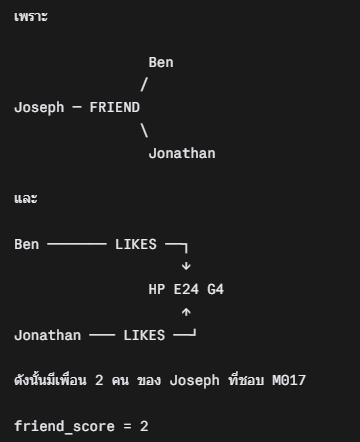

In [ ]:
def recommend_monitors(user_id):

    query = """
    MATCH
        (me:User {user_id:$user_id})
        -[:FRIEND_OF]-                  // หาเพื่อน (ทั้งสองทิศ)
        (friend:User)
        -[:LIKES]->                     // ดูว่าเพื่อนชอบจออะไร
        (monitor:Monitor)

    WHERE NOT EXISTS {

        MATCH
            (me)-[:LIKES]->(monitor)    // ตัดจอที่ตัวเองชอบอยู่แล้วออก

    }

    RETURN
        monitor.monitor_id AS monitor_id,
        monitor.name AS recommendation,
        count(DISTINCT friend) AS score // มีเพื่อนกี่คนที่ชอบจอนี้

    ORDER BY
        score DESC,
        recommendation
    """

    result = driver.execute_query(
        query,
        user_id=user_id,                # ส่งรหัส user เข้าไปใน $user_id
        database_=DATABASE
    )

    # แปลงผลเป็นตาราง pandas แล้วส่งกลับ
    return pd.DataFrame(
        [record.data() for record in result.records]
    )

In [ ]:
recommend_monitors("U005")

,monitor_id,recommendation,score
0,M014,ASUS ProArt PA278CV,1
1,M011,Dell UltraSharp U2723QE,1


In [ ]:
def find_user(user_id):

    result = driver.execute_query(
        """
        MATCH (u:User {user_id:$user_id})   // หา user จากรหัส

        RETURN
            u.user_id AS id,
            u.name AS name
        """,

        user_id=user_id,
        database_=DATABASE
    )

    # ถ้าหาไม่เจอ ให้แจ้งกลับไป
    if len(result.records) == 0:
        return "ไม่พบผู้ใช้"

    return result.records[0].data()

In [ ]:
find_user("U003")

{'id': 'U003', 'name': 'Jack'}

In [ ]:
def liked_monitors(user_id):

    result = driver.execute_query(
        """
        MATCH
            (u:User {user_id:$user_id})
            -[r:LIKES]->                  // เดินตามเส้น "ชอบ"
            (m:Monitor)

        RETURN
            m.monitor_id AS monitor_id,
            m.name AS name

        ORDER BY monitor_id               // เรียงตามรหัสจอ
        """,

        user_id=user_id,
        database_=DATABASE
    )

    # แปลงผลเป็นตาราง pandas แล้วส่งกลับ
    return pd.DataFrame(
        [record.data() for record in result.records]
    )

In [ ]:
liked_monitors("U005")

,monitor_id,name
0,M012,BenQ PD2700U
1,M013,LG UltraFine 27UP850
2,M015,Eizo ColorEdge CS2731


In [ ]:
result = driver.execute_query(
    """
    MATCH (n)

    OPTIONAL MATCH (n)-[r]->()   // นับเส้นที่ออกจากแต่ละ node

    RETURN
        count(DISTINCT n) AS nodes,
        count(r) AS relationships
    """,
    database_=DATABASE
)

print(result.records[0].data())

{'nodes': 30, 'relationships': 40}
